# 第三部分：巴西电商用户行为分析 - 可视化分析与业务洞察
## 3.可视化分析与业务洞察
## 3.1用户行为分析
- 3.1.1 用户订单分布（验证用户只有一个订单）
- 3.1.2用户消费能力
- 3.1.2.1用户客单价箱线图
- 3.1.2.2查找极端高客单价的异常值和处理异常值
用于分析异常值是否合理
- 3.1.2.3查找0元订单的异常值和处理异常值
用于分析异常值是否合理
## 3.1.3 用户活跃时间
- 3.1.3.1每月订单量趋势
- 3.1.3.2每月订单量折线图
## 3.2订单表现分析
- 3.2.1订单金额分布

##

## 3.可视化分析与业务洞察

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示，作用于 matplotlib/seaborn 绘制的图表
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac中文显示
plt.rcParams['axes.unicode_minus'] = False

In [181]:
# 加载客户-明细表
customer_order_merge = pd.read_csv('brazil_ecommerce_project/customer_order_merge.csv')

#加载订单明细表
order_merge = pd.read_csv('brazil_ecommerce_project/order_merge.csv')

#加载产品-商家表
product_seller_merge = pd.read_csv('brazil_ecommerce_project/product_seller_merge.csv')

In [182]:
# 加载用户特征表
user_features = pd.read_csv('brazil_ecommerce_project/用户维度特征表/user_features.csv')

#加载订单特征表
order_features = pd.read_csv('brazil_ecommerce_project/订单维度特征表/order_features.csv')

#加载产品特征表
category_features = pd.read_csv('brazil_ecommerce_project/产品维度特征表/category_features.csv')

#####

## 3.1用户行为分析

### 3.1.1 用户订单分布（验证用户只有一个订单）

<Axes: title={'center': '客户订单分布'}, xlabel='订单数', ylabel='用户数'>

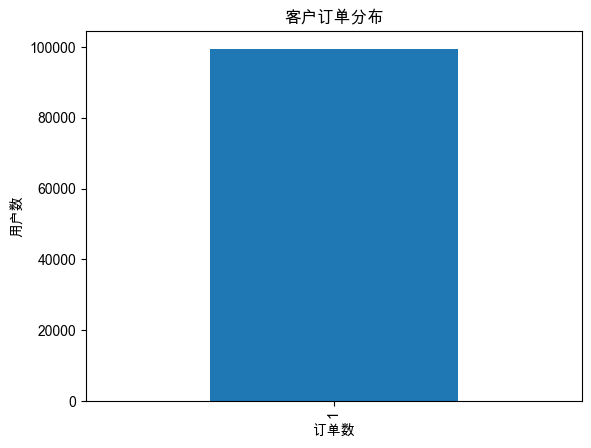

In [26]:
# 订单数分布直方图（展示不同订单数对应的用户数量）
order_count = user_features['order_count'].value_counts()
order_count.plot.bar(title='客户订单分布', xlabel='订单数', ylabel='用户数')

#### 结论：由于数据中所有用户的订单数都是1（之前已验证），所以图表只显示一根柱子，高度为99441。

#####

### 3.1.2用户消费能力

### 3.1.2.1用户客单价箱线图

<Axes: title={'center': '用户客单价箱线图'}>

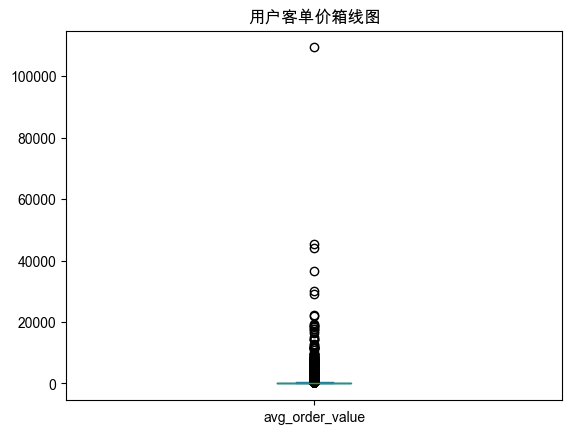

In [190]:
# 客户单价分布箱线图
user_features['avg_order_value'].plot.box(title='用户客单价箱线图')

### 结论：存在极端高客单价和少量0元订单

#####

### 3.1.2.2查找极端高客单价的异常值和处理异常值
用于分析异常值是否合理

In [183]:
# 取客单价里最大的10个值，看是否属于真的异常值
# 利用 merge 将用户特征表、客户-订单表连接起来
user_check = user_features[['customer_id', 'avg_order_value']].merge(customer_order_merge[[
    'customer_id', 'order_id']], on='customer_id', how='left')

# 再把产品-商家表连接起来
user_check = user_check.merge(product_seller_merge[[
    'order_id', 'product_category_name','product_id']], on='order_id', how='left')

# 有的用户购买了多个商品,导致 merge 后该用户出现多行
# 去重保留第一次出现的商品类别
user_check = user_check.drop_duplicates(subset=['customer_id', 'avg_order_value'])

# 取客单价里最大的10个值
user_check[['customer_id', 'avg_order_value', 'product_category_name'
           ]].nlargest(10,'avg_order_value')


,customer_id,avg_order_value,product_category_name
9793,1617b1357756262bfa56ab541c47bc16,109312.64,telefonia_fixa
84217,bd5d39761aa56689a265d95d8d32b8be,45256.00,automotivo
84520,be1b70680b9f9694d8c70f41fa3dc92b,44048.00,informatica_acessorios
2396,05455dfa7cd02f13d132aa7a6a9729c6,36489.24,agro_industria_e_comercio
14199,1ff773612ab8934db89fd5afa8afe506,30186.00,bebidas
104911,ec5b2ba62e574342386871631fafd3fc,29099.52,telefonia_fixa
102925,e7d6802668de6e74d0d6c56565bf2a24,22346.60,moveis_escritorio
62023,8c20d9bfbc96c5d39025d77a3ba83d7f,21874.05,moveis_escritorio
109679,f7622098214b4634b7fe7eee269b5426,19457.04,sinalizacao_e_seguranca
50213,71901689c5f3e5adc27b1dd16b33f0b8,19174.38,informatica_acessorios


### 结论：高客单价品类集中在大件 / 高价值商品（固定电话、汽车、办公家具、安防设备等）

In [184]:
# 筛选出高客单价用户的订单明细（以客单价最高的用户为例）
high_user = user_check.nlargest(10,'avg_order_value')['customer_id'].tolist()
high_order = order_merge[order_merge['customer_id'].isin(high_user)]

# 查看这些订单的详细商品信息(商品件数，总价，以及对应的产品类别）
high_orders = high_order.groupby('order_id').agg(order_count=('order_id','count'), avg_price=(
    'payment_value','mean'), total_price=('payment_value', 'sum')).sort_values(
    'total_price', ascending=False).reset_index()

# 连接user_check表，用于查看件数和总价对应的产品类别
high_orders = high_orders.merge(user_check[['order_id', 'product_category_name'
                             ]], on='order_id', how='left')
high_orders

,order_id,order_count,avg_price,total_price,product_category_name
0,03caa2c082116e1d31e67e9ae3700499,8,13664.08,109312.64,telefonia_fixa
1,ab14fdcfbe524636d65ee38360e22ce8,20,2262.80,45256.00,automotivo
2,1b15974a0141d54e36626dca3fdc731a,20,2202.40,44048.00,informatica_acessorios
3,2cc9089445046817a7539d90805e6e5a,6,6081.54,36489.24,agro_industria_e_comercio
4,e8fa22c3673b1dd17ea315021b1f0f61,10,3018.60,30186.00,bebidas
5,736e1922ae60d0d6a89247b851902527,4,7274.88,29099.52,telefonia_fixa
6,9aec4e1ae90b23c7bf2d2b3bfafbd943,10,2234.66,22346.60,moveis_escritorio
7,71dab1155600756af6de79de92e712e3,11,1988.55,21874.05,moveis_escritorio
8,912343626f370ead5ef2e85a9d757e22,6,3242.84,19457.04,sinalizacao_e_seguranca
9,4412d97cb2093633afa85f11db46316c,6,3195.73,19174.38,informatica_acessorios


### 从分析结果可以看出，客单价最高的10个订单具有以下特征：
- 商品件数较多（4至20件），平均单价显著高于普通订单。
- 产品类别集中在固定电话设备、汽车配件、信息技术配件、农业工业、饮料、办公家具、安全标识等偏向工业或商业用途的品类。
- 这些品类多为企业级采购或大宗交易，而非普通消费品，因此高客单价可能是合理的批量采购行为，而非数据错误。

### 结论：
- 高客单价订单主要由企业级或批量采购驱动，集中在特定工业/商业品类，建议在后续分析中将其作为独立群体研究，或为这类客户提供定制化服务。

#####

### 3.1.2.3查找0元订单的异常值和处理异常值
用于分析异常值是否合理

In [187]:
# 筛选出高0元客单价用户的订单明细（以客单价0元的用户为例）
zero_orders = user_features[user_features['avg_order_value'] == 0]['customer_id'].tolist()
zero_orders_info = order_merge[order_merge['customer_id'].isin(zero_orders)]

# 查找重复值并去重
zero_orders_info.duplicated('order_id')
zero_orders_info = zero_orders_info.drop_duplicates(['order_id','customer_id'])

# 查看0元客单价的订单明细
zero_orders_info[[
    'order_id', 'customer_id','order_status', 'order_delivered_customer_date', 'payment_value']]

,order_id,customer_id,order_status,order_delivered_customer_date,payment_value
1362,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,NaN,0.0
36864,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-11-09 07:47:38,NaN
47855,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,canceled,NaN,0.0
48231,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,canceled,NaN,0.0


### 经排查，共发现4个0元订单，其中3个为已取消订单（状态正常），1个为数据异常（已送达但支付金额缺失）
建议删除已送达但金额缺失的这笔订单（因为它会影响客单价、销售额等指标），其余3笔取消的0元订单可保留

In [188]:
# 删除指定订单
order_merge = order_merge[order_merge['order_id'] != 'bfbd0f9bdef84302105ad712db648a6c']

# 删除指定用户
user_features = user_features[user_features['customer_id'] != '86dc2ffce2dfff336de2f386a786e574']

#####

### 3.1.3 用户活跃时间

### 3.1.3.1每月订单量趋势

In [244]:
# 先去重,因为一个订单可能有多个商品，但只能算一个订单
monthly_orders = order_merge.drop_duplicates(['order_id', 'customer_id']).copy()

#设置时间格式
monthly_orders['order_purchase_timestamp'] = pd.to_datetime(monthly_orders[
    'order_purchase_timestamp'])

#设置购买时间列为索引
monthly_orders = monthly_orders.set_index('order_purchase_timestamp')

#降采样，计算每月的订单数
monthly_orders = monthly_orders['order_id'].resample('ME').count()

#时间索引转换到月周期
monthly_orders.index = monthly_orders.index.to_period()
#重置索引
monthly_orders = monthly_orders.reset_index()
#重置列名
monthly_orders.rename(columns={'order_purchase_timestamp':'monthly','order_id':'order_count'
                              }, inplace=True)
monthly_orders.head()

,monthly,order_count
0,2016-09,3
1,2016-10,324
2,2016-11,0
3,2016-12,1
4,2017-01,800


### 3.1.3.2每月订单量折线图

<Axes: title={'center': '每月订单量趋势'}, xlabel='monthly_str'>

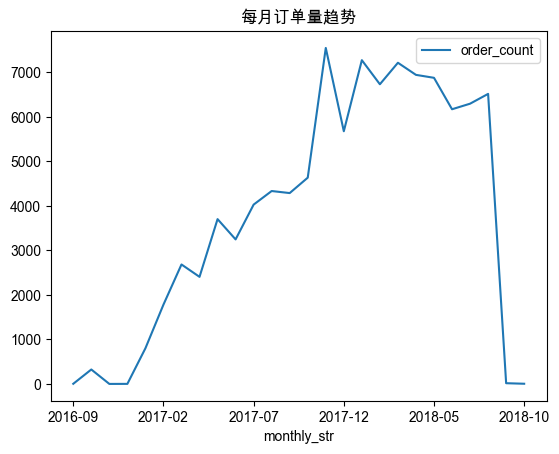

In [250]:
# 先把 monthly 列转成「年-月」字符串格式,用于横坐标显示完整的时间
monthly_orders['monthly_str'] = monthly_orders['monthly'].astype(str)

monthly_orders.plot(x='monthly_str', y='order_count', title='每月订单量趋势')

### 结论：整体增长：从2016年9月至2018年10月，订单量呈现显著上升趋势，10月订单量回落至27单
- 起步期（2016年9月—12月）：订单量极少，月均不足百单，属于数据积累初期。
- 快速增长期（2017年—2018年）：2017年初订单量突破800，此后稳步攀升，至2018年下半年月订单量超过7000，增长近10倍。
- 异常月份：2016年11月订单量为0，可能是数据缺失或业务暂停，需注意数据覆盖的完整性。

#####

## 3.2订单表现分析

### 3.2.1订单金额分布

<Axes: title={'center': '订单金额分布（0-1000元区间）'}, xlabel='订单金额（元）', ylabel='订单数'>

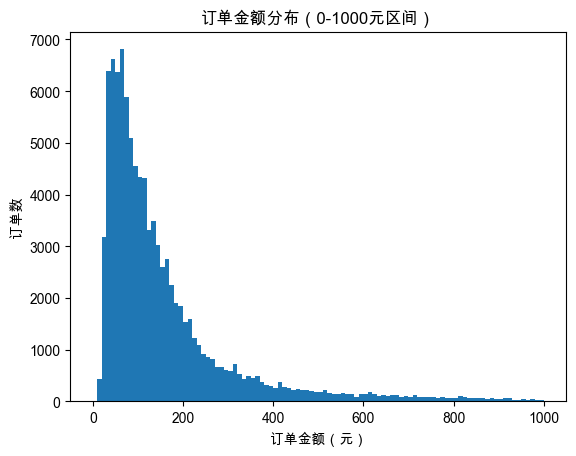

In [274]:
order_total_prices = order_merge.groupby('order_id')['payment_value'].sum()
order_total_prices.plot.hist(bins=100,range=(
    0, 1000), title='订单金额分布（0-1000元区间）', xlabel='订单金额（元）', ylabel='订单数')

In [278]:
order_total_prices.describe(percentiles=[.5, .9, .95])

count     99440.000000
mean        206.955591
std         622.552967
min           0.000000
50%         110.240000
90%         387.670000
95%         644.082000
max      109312.640000
Name: payment_value, dtype: float64

### 结论：订单金额中位数为110.24元，平均值为206.96元，说明半数以上订单金额在110元左右，均值高于中位数反映分布右偏。
- 分布范围：90% 的订单金额在 387.67 元以下，95% 在 644.08 元以下，表明绝大部分订单集中于 0–500 元区间，与直方图显示一致。
- 极端值：存在少量极高金额订单（最大值达 109,312.64 元），显著拉高整体均值，这些可能对应企业采购或多件商品的大额交易。